In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os
import cv2
from ImageData import ImageDataset
from pca import PCA
from alignement import process_single_image

### Load ImageData object from binary with pickle

In [2]:
with open("../../data/image_matrix.pkl", "rb") as f:
    data = pickle.load(f)

print(type(data))

<class 'ImageData.ImageDataset'>


### Initialize a PCA object
**Looong runtime**<br>
Save to binary with pickle after running once to avoid re-running.

In [3]:
load = True
if load:
    print("loading PCA model from file...")
    with open("../../data/pca_model.pkl", "rb") as f:
        pca = pickle.load(f)
else:
    pca = PCA(n_components=300)
    pca.fit(data)

loading PCA model from file...


In [25]:
with open("../../data/pca_model.pkl", "wb") as f:
    pickle.dump(pca, f)

### Testing different reconstruction component counts
Try different n_components values to see how it affects reconstruction quality.

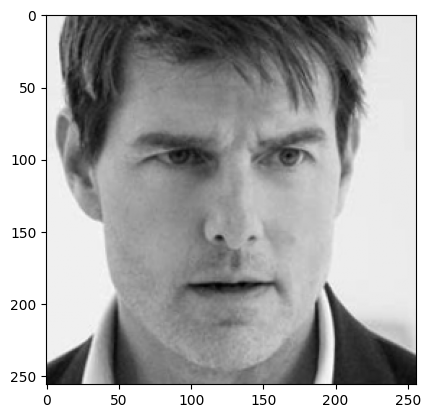

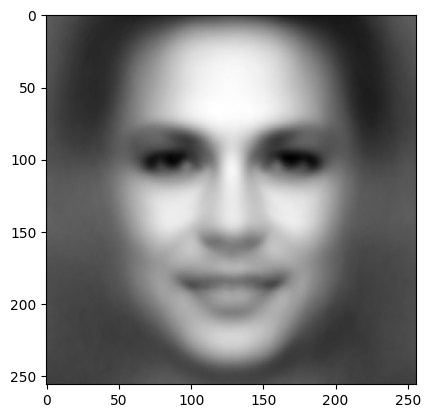

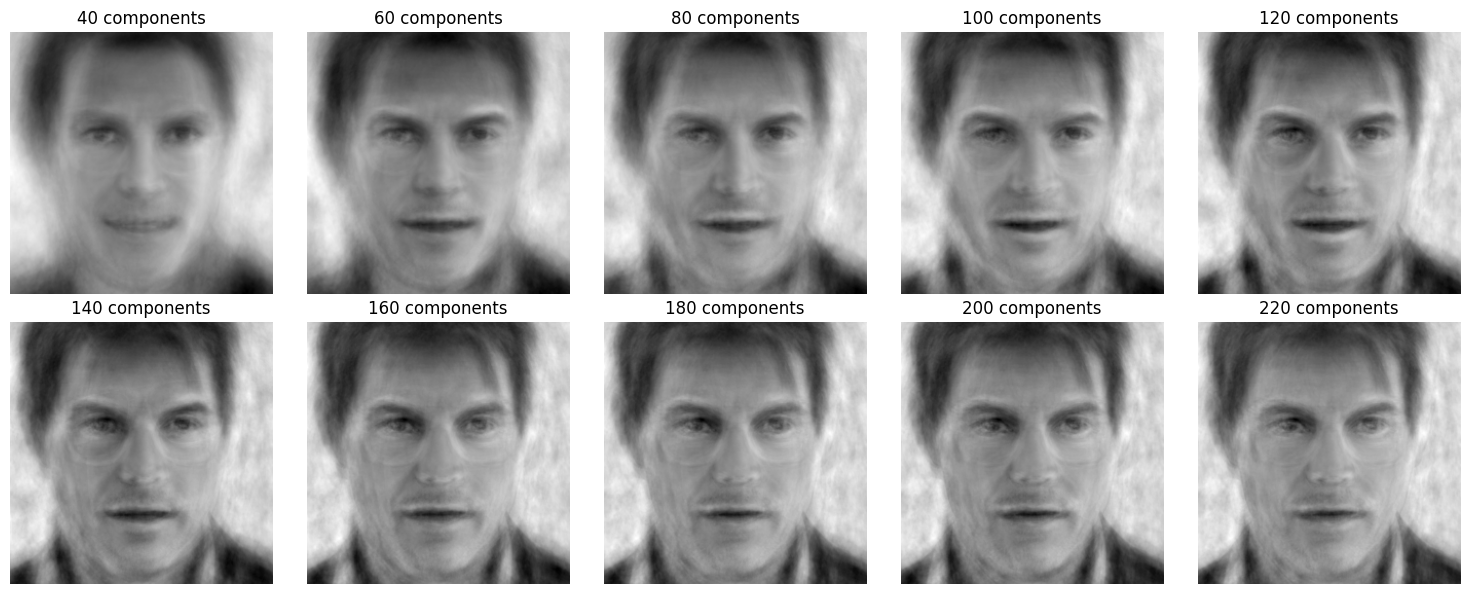

In [4]:
test_img = data[1510]
plt.imshow(test_img.reshape(data.image_height, data.image_width), cmap='gray')
plt.show()

plt.imshow(data.mean.reshape(data.image_height, data.image_width), cmap='gray')
plt.show()


test_img_reconstructed = []
for n in range(40, 240, 20):
    reconstructed, components_sub, X_transformed, mean = pca.reconstruct_n(test_img, n)
    test_img_reconstructed.append(reconstructed)


fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, (ax, img) in enumerate(zip(axes, test_img_reconstructed)):
    ax.imshow(img.reshape(data.image_height, data.image_width), cmap='gray')
    ax.set_title(f'{(i + 2)*20} components')
    ax.axis('off')

plt.tight_layout()
plt.show()


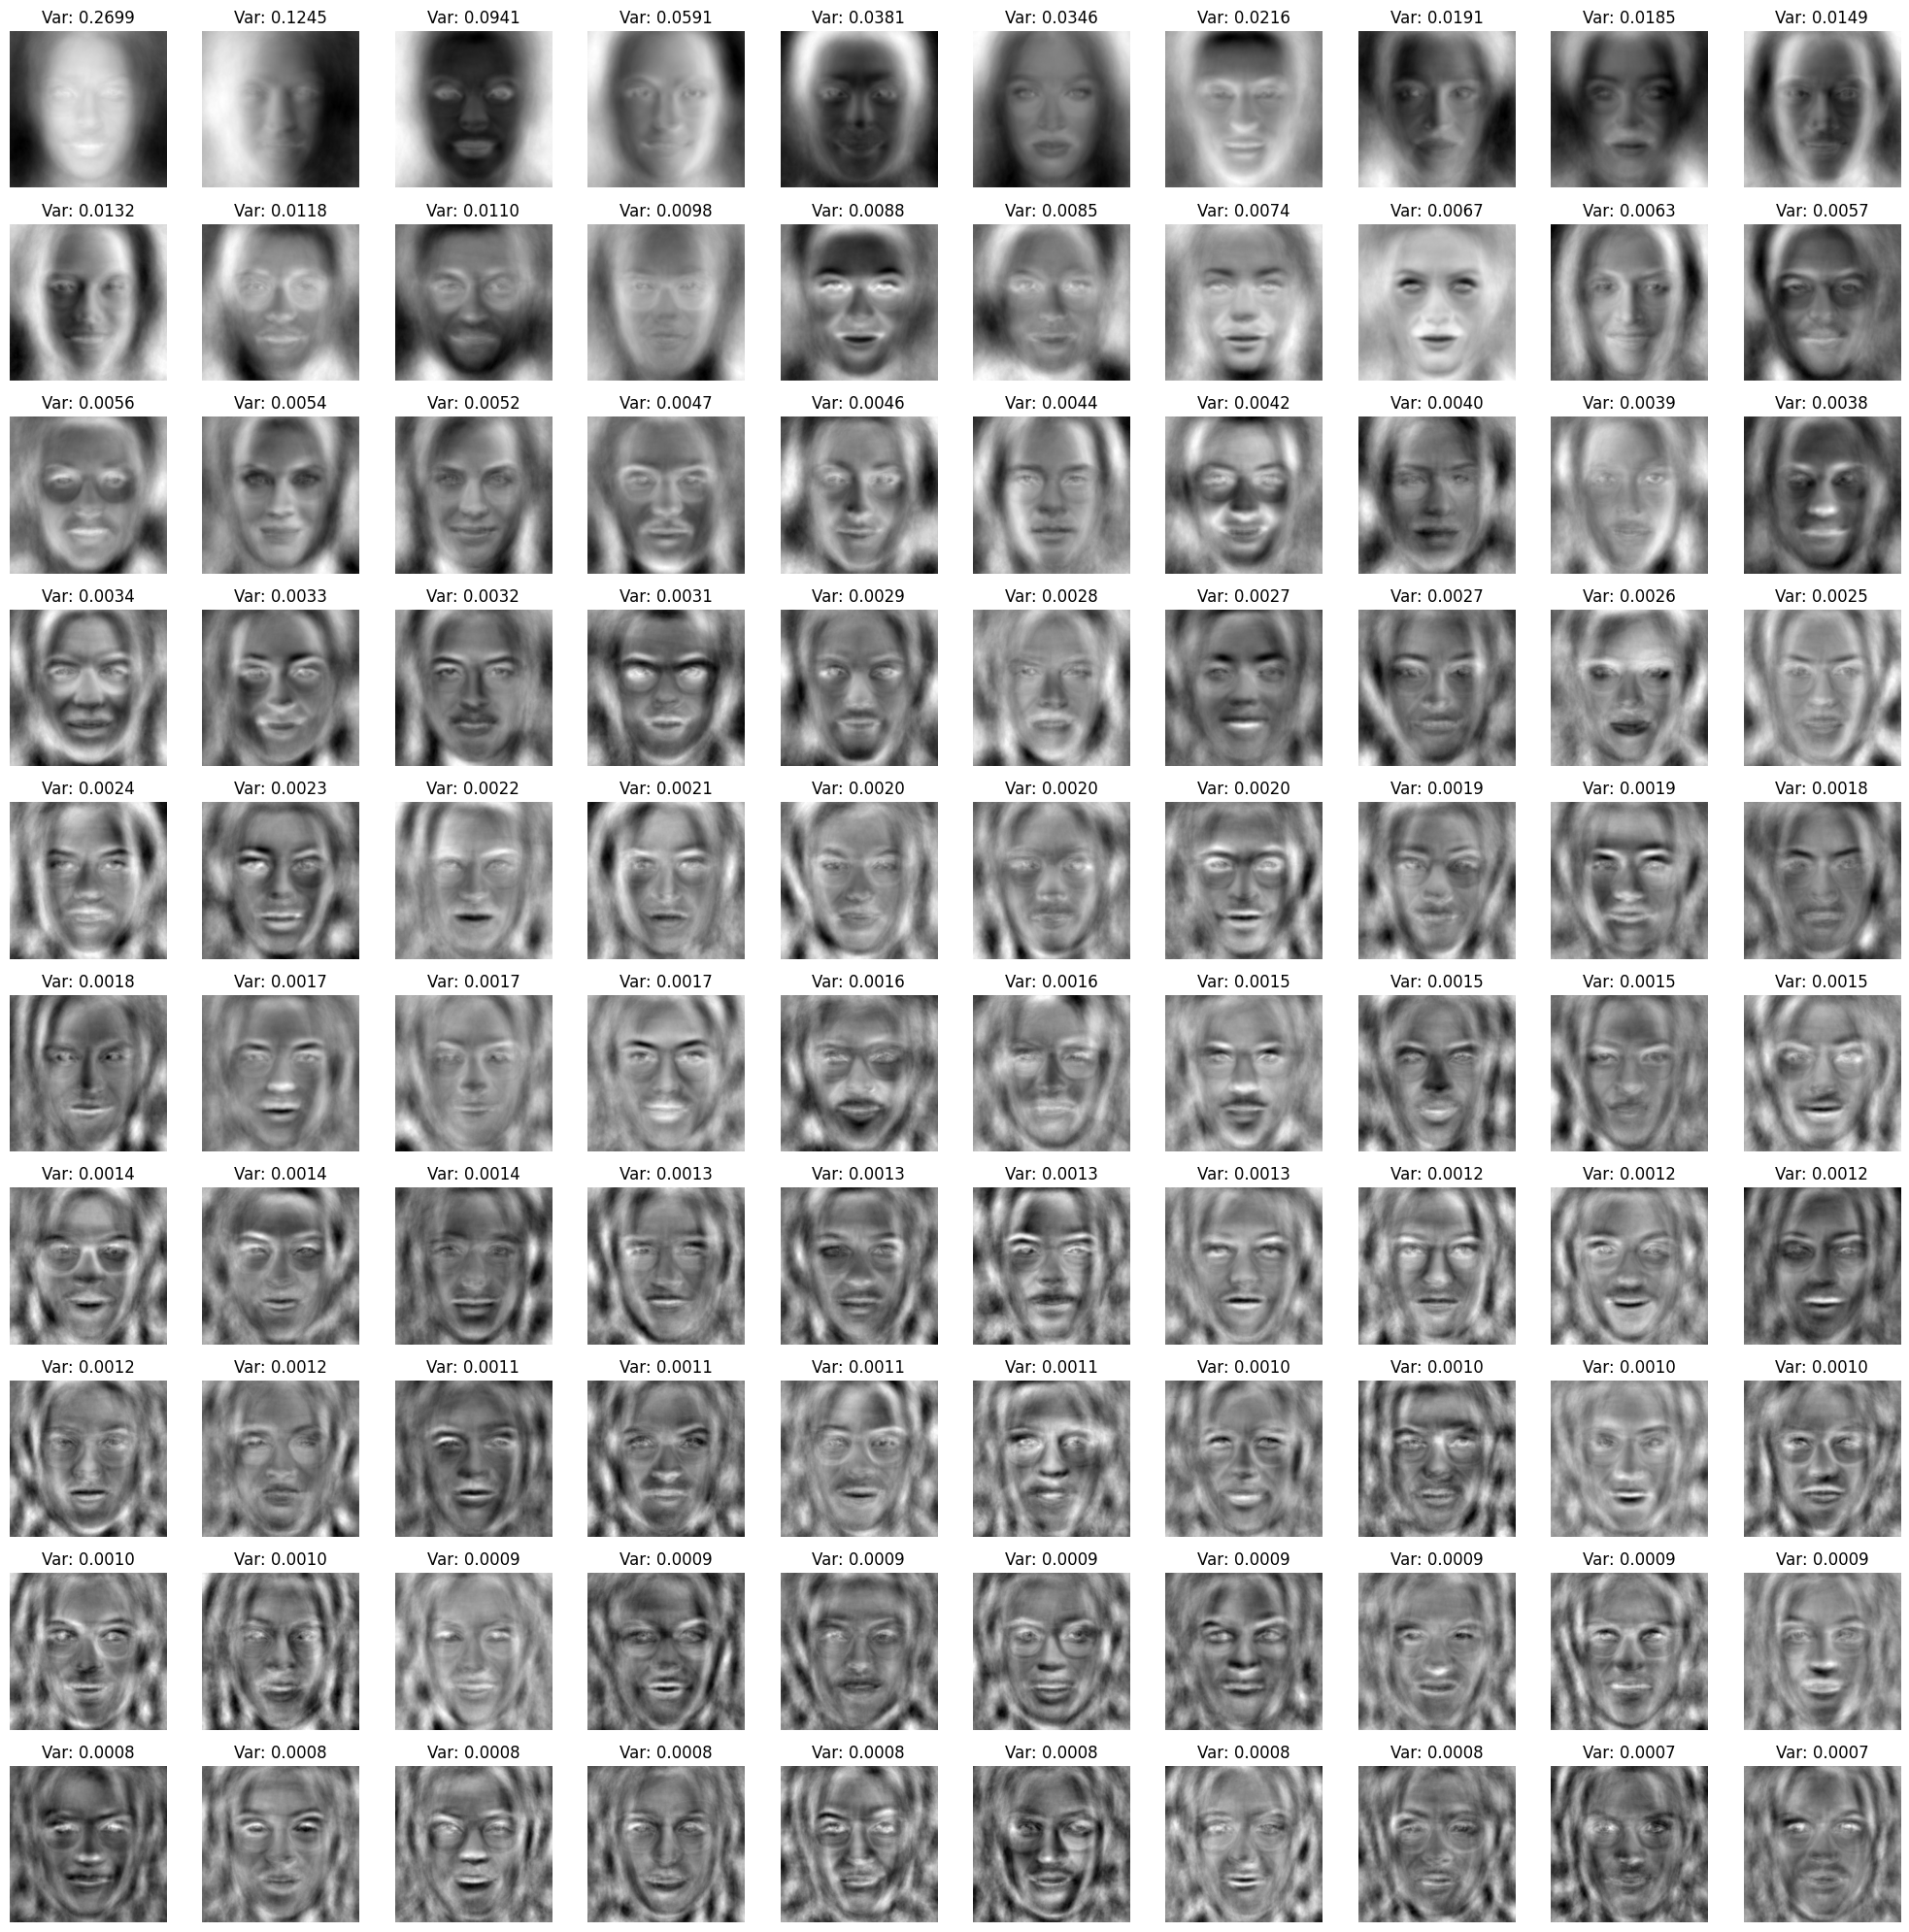

In [29]:
components = pca.components
eigenvals, explained_variance = pca.explained_variance()

fig, axes = plt.subplots(10, 10, figsize=(20, 20))
axes = axes.flatten()

for i in range(100):
    ax = axes[i]
    ax.imshow(components[:,i].reshape(data.image_height, data.image_width), cmap='gray')
    ax.set_title(f'Var: {explained_variance[i]:.4f}')
    ax.axis('off')
plt.tight_layout()
plt.show()


**As the principal components have been computed on a set of images of only 18 different celbrities, I am expecting it to be sort of "overfitted" to this specific dataset. This means that while the PCA model may perform well on these images, it might not generalize effectively to new, unseen images of different people. I try to project and reconstruct an image of me!**


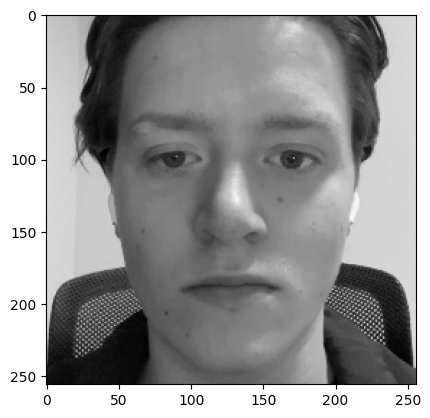

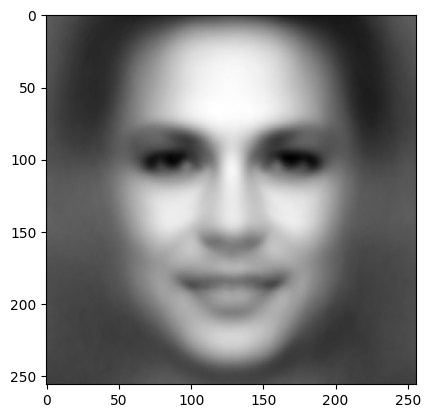

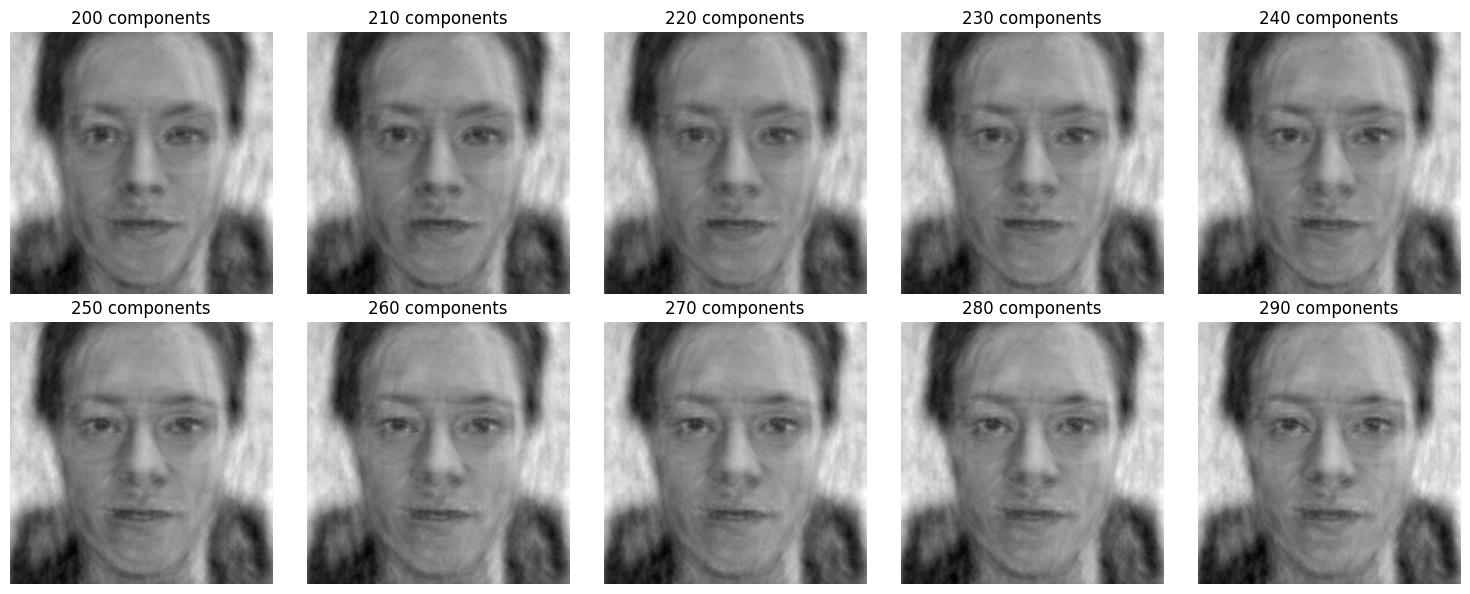

In [10]:
selfie_path = "../../data/nico_selfie.jpg"
aligned_success, info = process_single_image(
    selfie_path,
    out_path="../../data/nico_selfie_aligned.jpg",
    grayscale_after=True,
    normalize_0_1=True,
    min_conf=0.9
)

selfie = cv2.imread("../../data/nico_selfie_aligned.jpg", cv2.IMREAD_GRAYSCALE)

plt.imshow(selfie, cmap='gray')
plt.show()
plt.imshow(data.mean.reshape(data.image_height, data.image_width), cmap='gray')

selfie_transformed = pca.transform(selfie.flatten())


test_img_reconstructed = []
for n in range(200, 310, 10):
    reconstructed, components_sub, X_transformed, mean = pca.reconstruct_n(selfie.flatten(), n)
    test_img_reconstructed.append(reconstructed)


fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, (ax, img) in enumerate(zip(axes, test_img_reconstructed)):
    ax.imshow(img.reshape(data.image_height, data.image_width), cmap='gray')
    ax.set_title(f'{(i + 20)*10} components')
    ax.axis('off')

plt.tight_layout()
plt.show()



### Another one

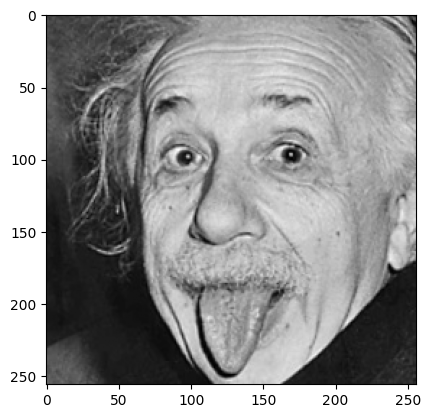

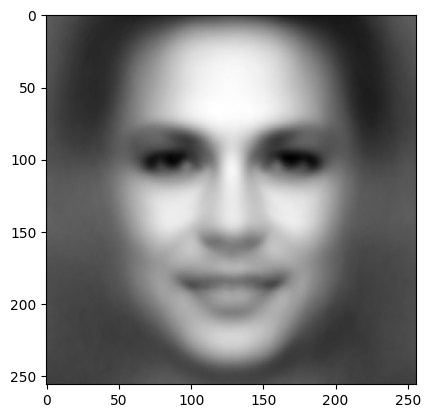

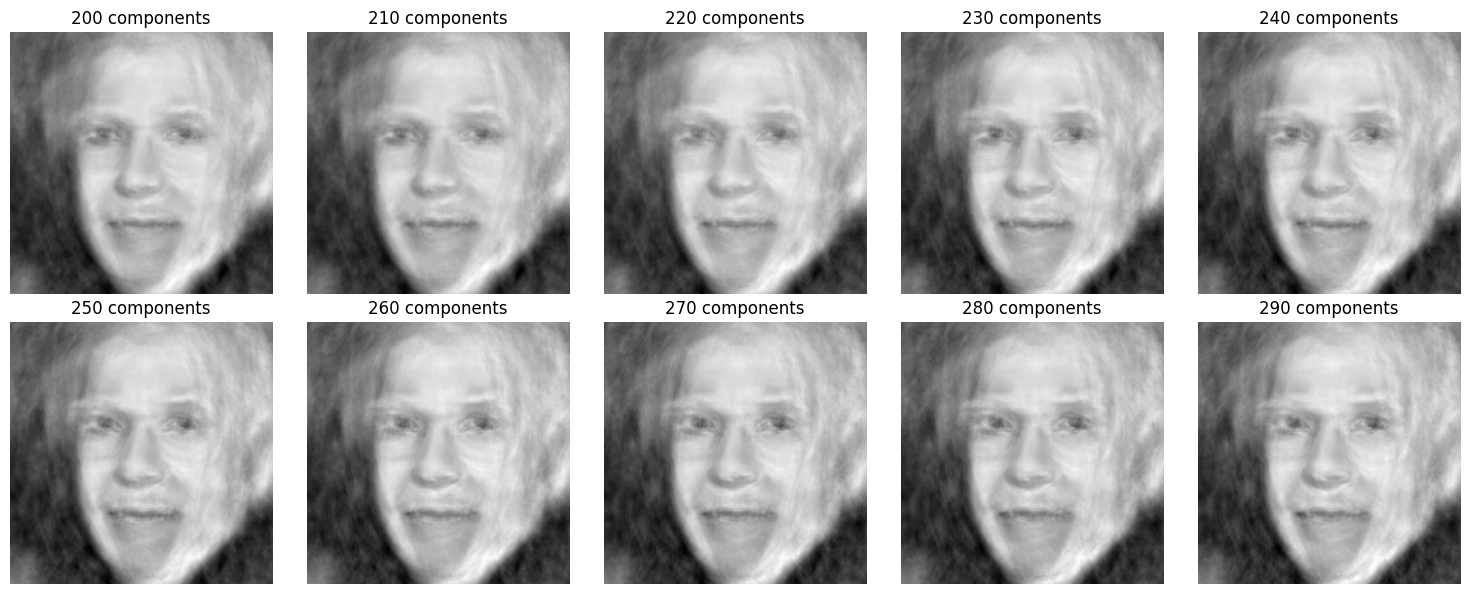

In [11]:
selfie_path = "../../data/einstein.jpg"
aligned_success, info = process_single_image(
    selfie_path,
    out_path="../../data/einstein_aligned.jpg",
    grayscale_after=True,
    normalize_0_1=True,
    min_conf=0.9
)

selfie = cv2.imread("../../data/einstein_aligned.jpg", cv2.IMREAD_GRAYSCALE)

plt.imshow(selfie, cmap='gray')
plt.show()
plt.imshow(data.mean.reshape(data.image_height, data.image_width), cmap='gray')

selfie_transformed = pca.transform(selfie.flatten())


test_img_reconstructed = []
for n in range(200, 310, 10):
    reconstructed, components_sub, X_transformed, mean = pca.reconstruct_n(selfie.flatten(), n)
    test_img_reconstructed.append(reconstructed)


fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, (ax, img) in enumerate(zip(axes, test_img_reconstructed)):
    ax.imshow(img.reshape(data.image_height, data.image_width), cmap='gray')
    ax.set_title(f'{(i + 20)*10} components')
    ax.axis('off')

plt.tight_layout()
plt.show()



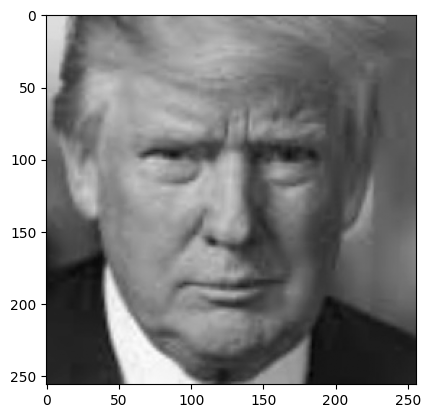

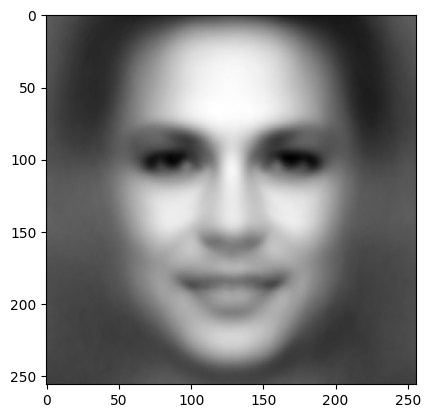

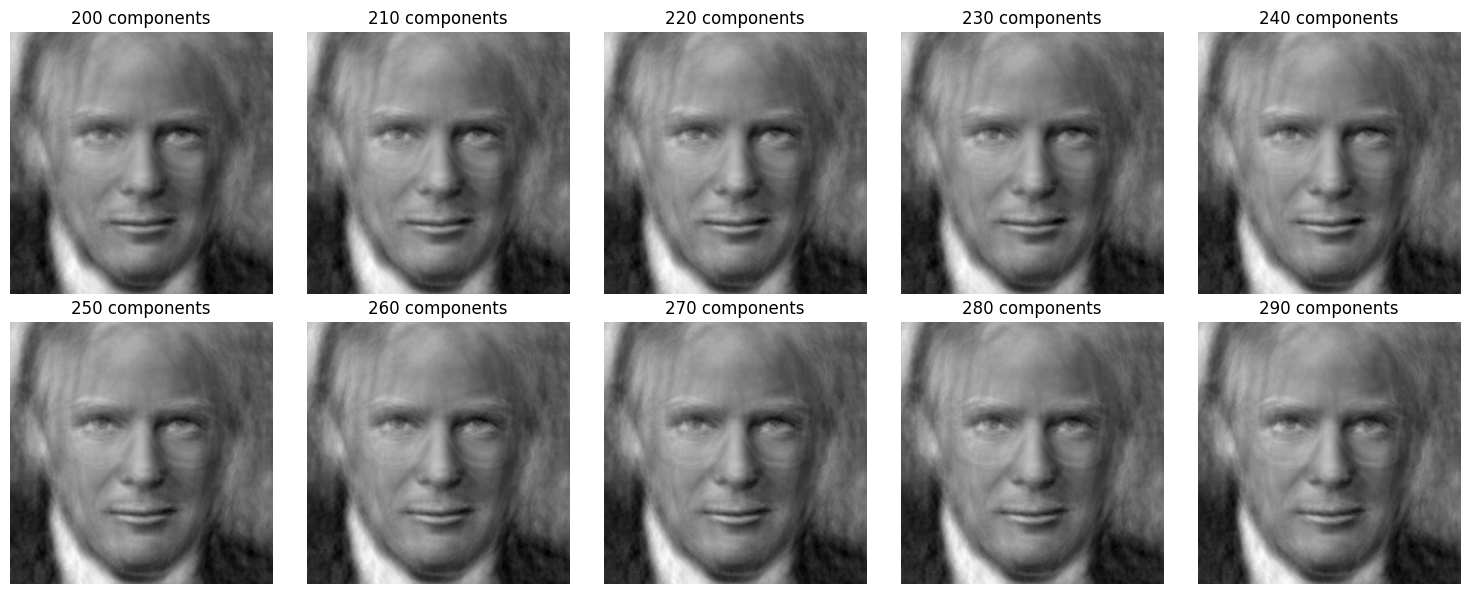

In [12]:
selfie_path = "../../data/trump.jpg"
aligned_success, info = process_single_image(
    selfie_path,
    out_path="../../data/trump_aligned.jpg",
    grayscale_after=True,
    normalize_0_1=True,
    min_conf=0.9
)

selfie = cv2.imread("../../data/trump_aligned.jpg", cv2.IMREAD_GRAYSCALE)

plt.imshow(selfie, cmap='gray')
plt.show()
plt.imshow(data.mean.reshape(data.image_height, data.image_width), cmap='gray')

selfie_transformed = pca.transform(selfie.flatten())


test_img_reconstructed = []
for n in range(200, 310, 10):
    reconstructed, components_sub, X_transformed, mean = pca.reconstruct_n(selfie.flatten(), n)
    test_img_reconstructed.append(reconstructed)


fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, (ax, img) in enumerate(zip(axes, test_img_reconstructed)):
    ax.imshow(img.reshape(data.image_height, data.image_width), cmap='gray')
    ax.set_title(f'{(i + 20)*10} components')
    ax.axis('off')

plt.tight_layout()
plt.show()

